In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('house price.csv')
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


# EDA

In [3]:
df.shape

(4600, 18)

In [4]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


# Missing Values

In [7]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [8]:
df.notnull().sum()

date             4600
price            4600
bedrooms         4600
bathrooms        4600
sqft_living      4600
sqft_lot         4600
floors           4600
waterfront       4600
view             4600
condition        4600
sqft_above       4600
sqft_basement    4600
yr_built         4600
yr_renovated     4600
street           4600
city             4600
statezip         4600
country          4600
dtype: int64

# Duplicated Values

In [9]:
df.duplicated().sum()

np.int64(0)

# Outliers Float

In [10]:
df.select_dtypes(include = 'float').columns

Index(['price', 'bedrooms', 'bathrooms', 'floors'], dtype='object')

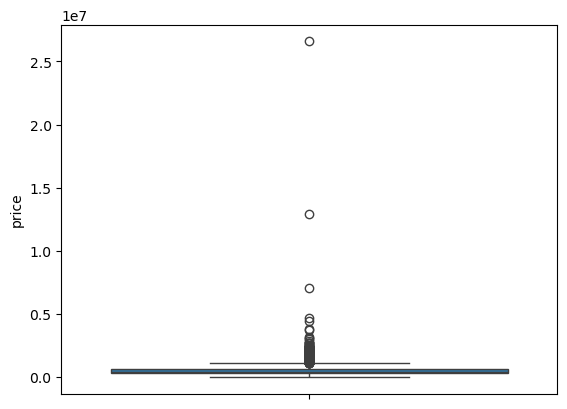

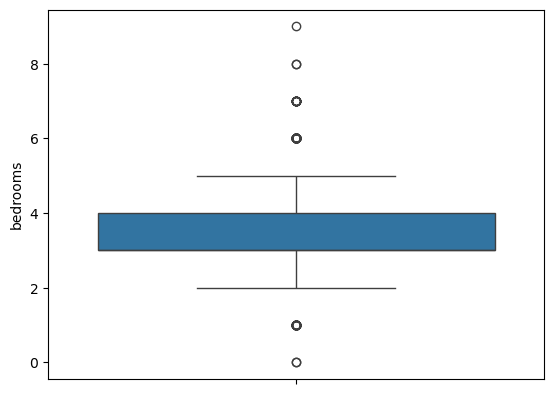

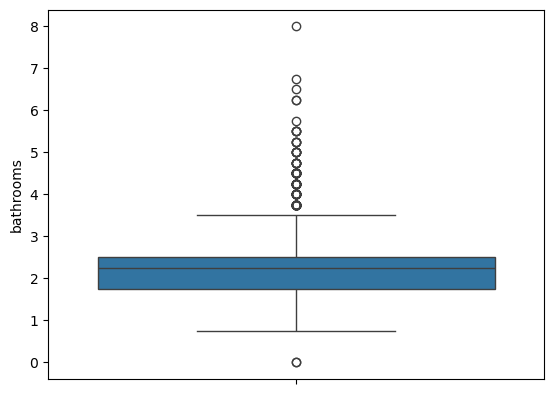

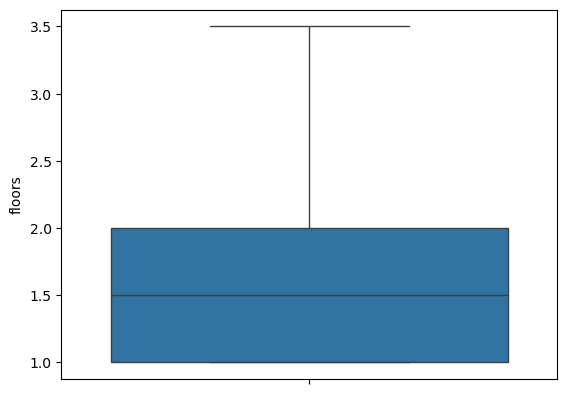

In [11]:
for i in df.select_dtypes(include = 'float').columns:
    sns.boxplot(df[i])
    plt.show()

In [12]:
for i in df.select_dtypes(include = 'float').columns:
    
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    
    IQR = q3 - q1
    
    min_range = q1 - 1.5 * IQR
    max_range = q3 + 1.5 * IQR
    
    df = df[(df[i] >= min_range) & (df[i] <= max_range)]

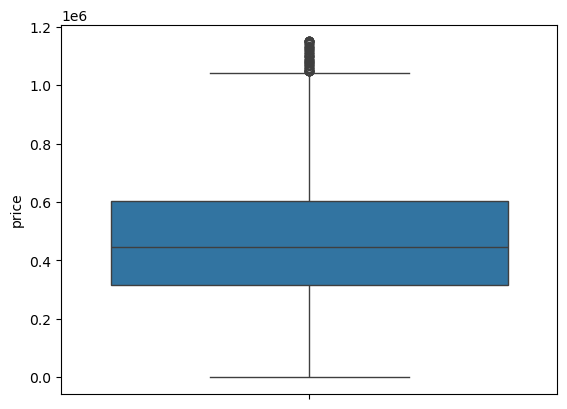

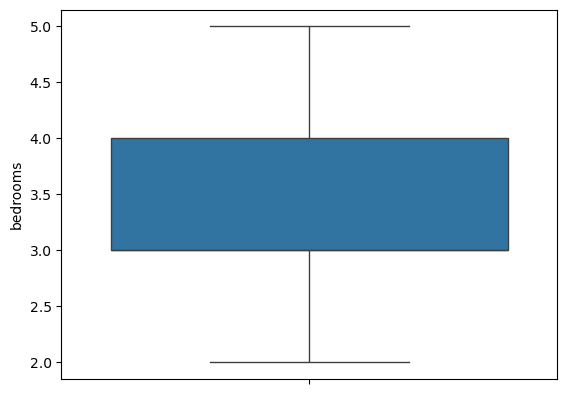

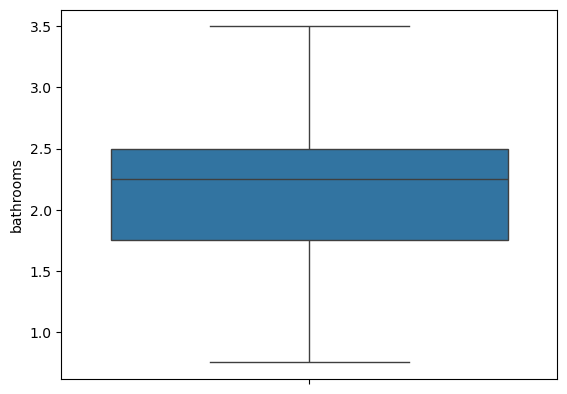

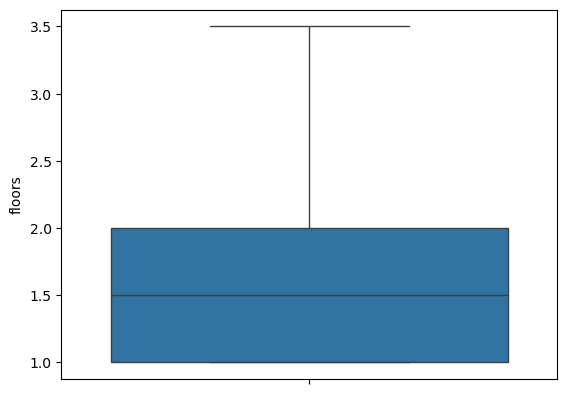

In [13]:
for i in df.select_dtypes(include = 'float').columns:
    sns.boxplot(df[i])
    plt.show()

# Outlier Int64

In [14]:
df.select_dtypes(include = 'int64').columns

Index(['sqft_living', 'sqft_lot', 'waterfront', 'view', 'condition',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated'],
      dtype='object')

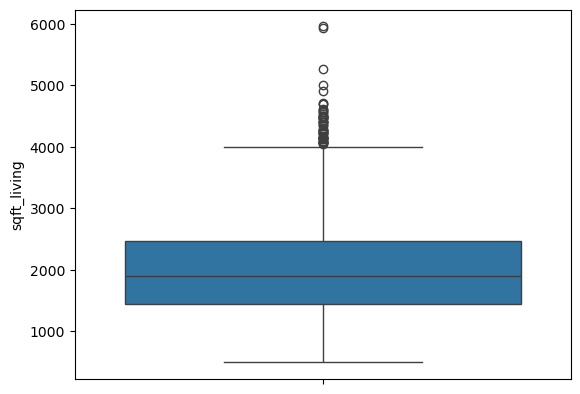

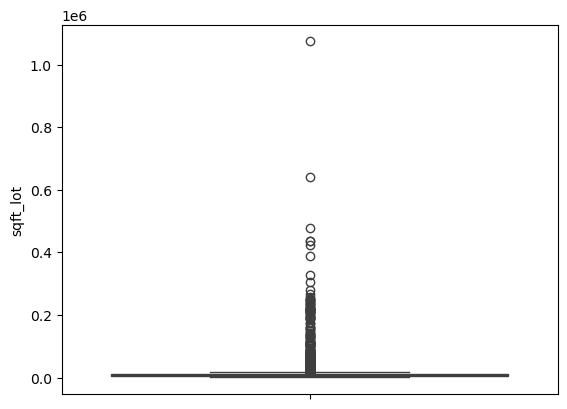

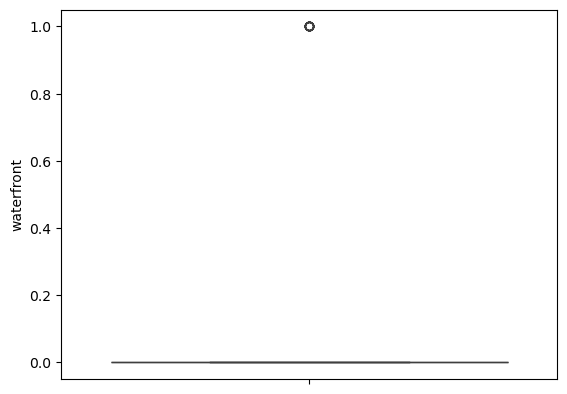

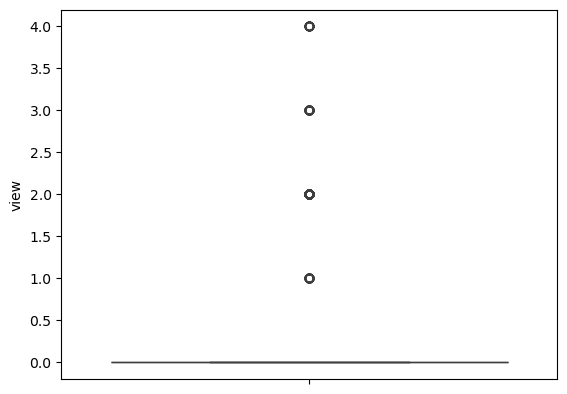

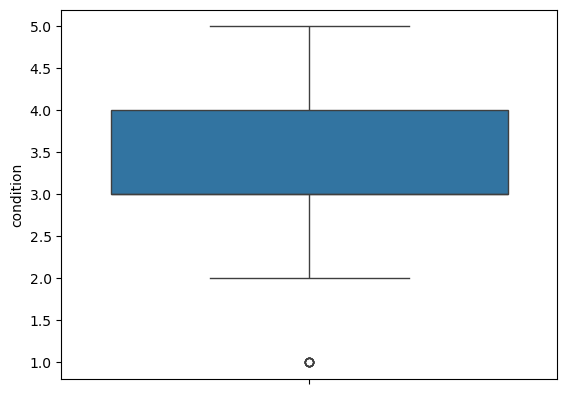

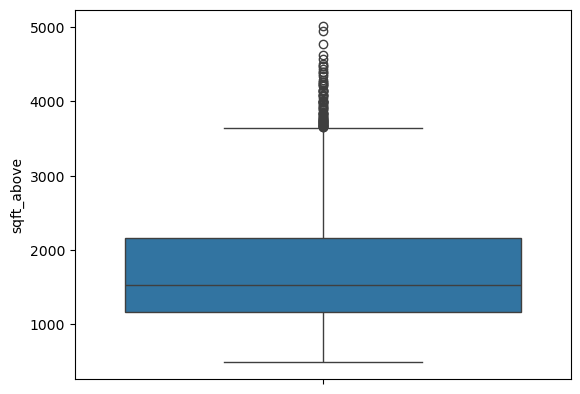

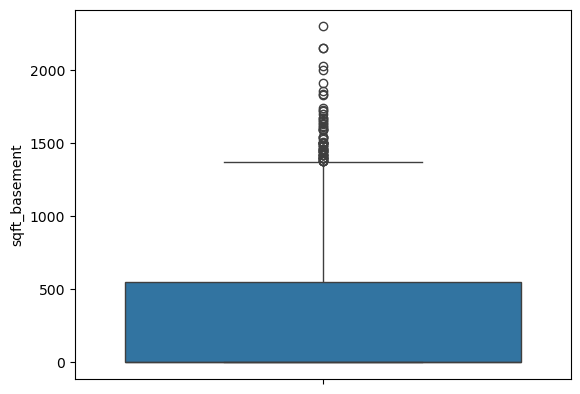

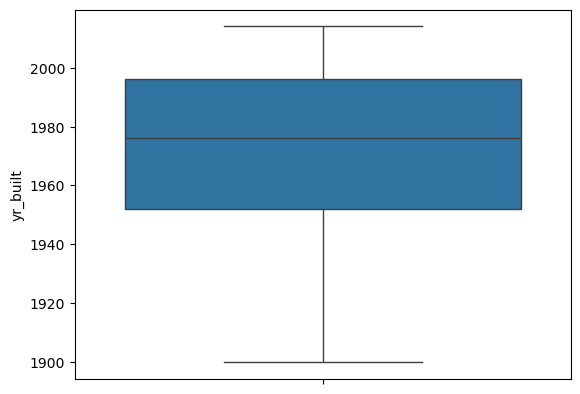

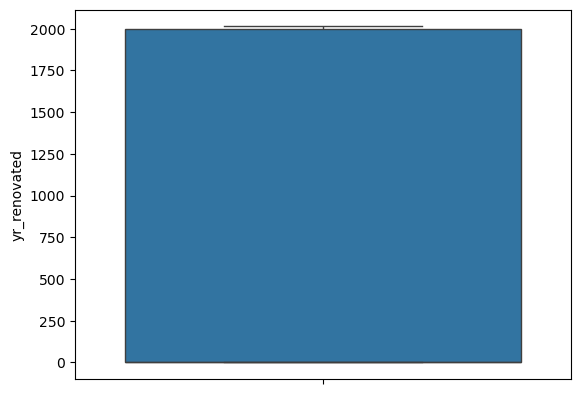

In [15]:
for i in df.select_dtypes(include = 'int64').columns:
    sns.boxplot(df[i])
    plt.show()

In [16]:
for i in df.select_dtypes(include = 'int64').columns:
    
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    
    IQR = q3 - q1
    
    min_range = q1 - 1.5 * IQR
    max_range = q3 + 1.5 * IQR
    
    df = df[(df[i] >= min_range) & (df[i] <= max_range)]

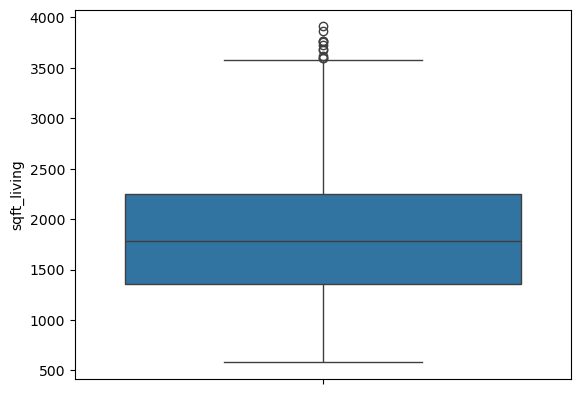

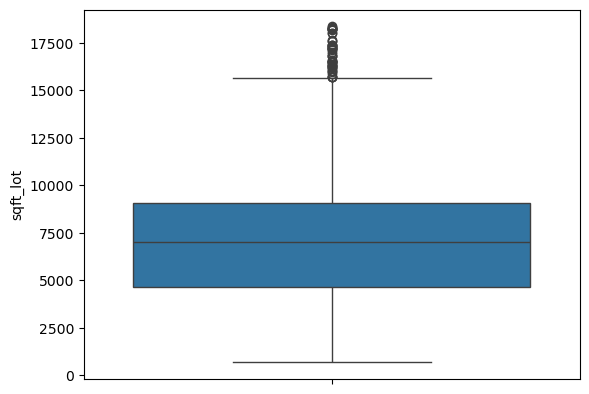

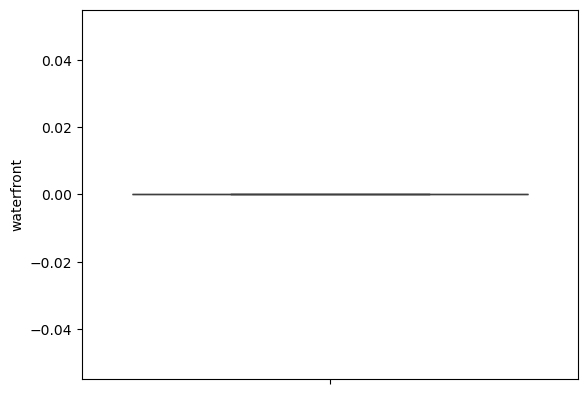

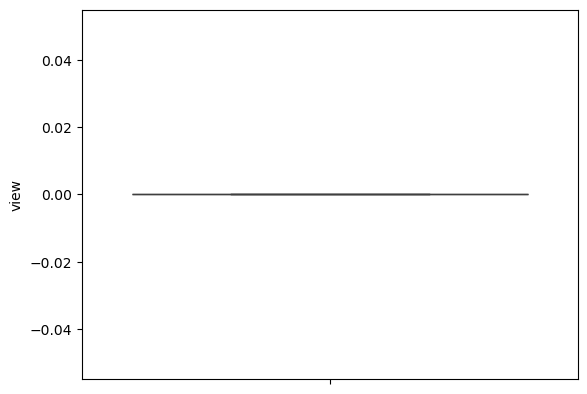

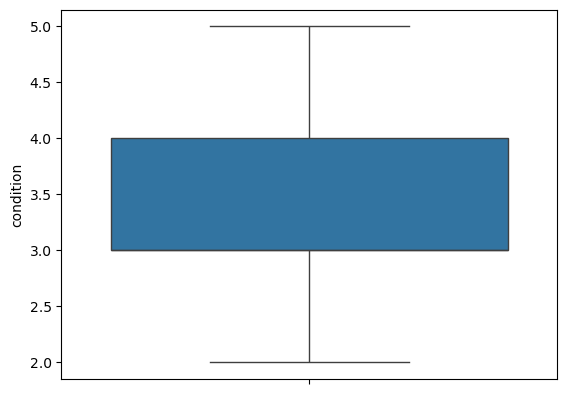

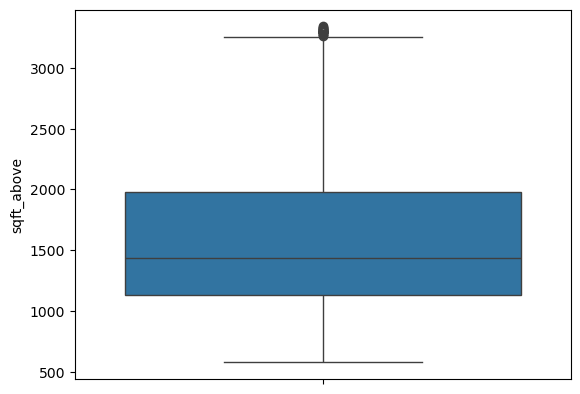

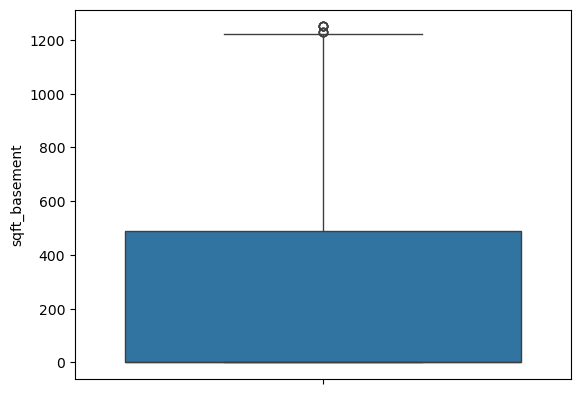

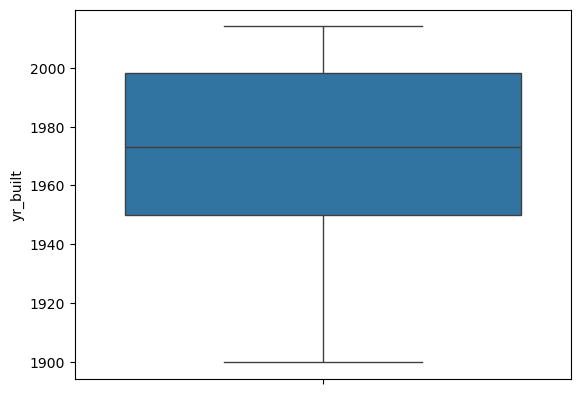

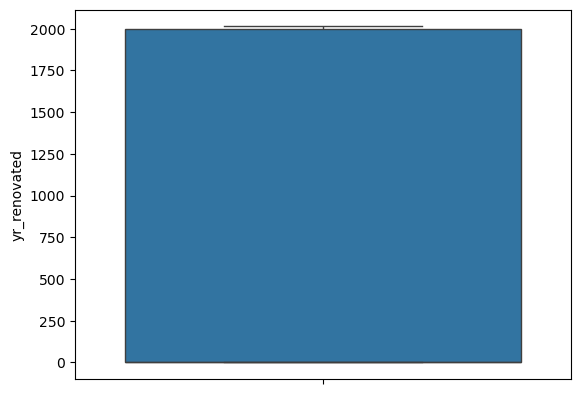

In [17]:
for i in df.select_dtypes(include = 'int64').columns:
    sns.boxplot(df[i])
    plt.show()

In [18]:
df.shape

(3316, 18)

# Independent Data & Dependent Data

In [19]:
df.select_dtypes(include = 'float').columns

Index(['price', 'bedrooms', 'bathrooms', 'floors'], dtype='object')

In [20]:
df.select_dtypes(include = 'int64').columns

Index(['sqft_living', 'sqft_lot', 'waterfront', 'view', 'condition',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated'],
      dtype='object')

In [21]:
x = df.drop(columns = ['price'], axis = 1)
y = df[['price']]

In [22]:
x

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
2,2014-05-02 00:00:00,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [23]:
y

,price
0,313000.000000
2,342000.000000
3,420000.000000
4,550000.000000
5,490000.000000
...,...
4595,308166.666667
4596,534333.333333
4597,416904.166667
4598,203400.000000


# Train Test Split

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [25]:
x_train.shape

(2652, 17)

In [26]:
x_test.shape

(664, 17)

In [27]:
y_train.shape

(2652, 1)

In [28]:
y_test.shape

(664, 1)

# One Hot Encoder

In [29]:
ohe = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
x_train_ohe = ohe.fit_transform(x_train)
x_test_ohe = ohe.transform(x_test)

In [30]:
x_train_ohe.shape

(2652, 5587)

In [31]:
x_test_ohe.shape

(664, 5587)

# Standard Scaler

In [32]:
ss = StandardScaler()
x_train_s = ss.fit_transform(x_train_ohe)
x_test_s = ss.transform(x_test_ohe)

In [33]:
x_train_s.shape

(2652, 5587)

In [34]:
x_test_s.shape

(664, 5587)

# Linear Regression

In [37]:
lr = LinearRegression()
lr.fit(x_train_s, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Prediction

In [38]:
x_train_pred = lr.predict(x_train_s)
x_test_pred = lr.predict(x_test_s)

In [40]:
x_train_pred.shape

(2652, 1)

In [41]:
x_test_pred.shape

(664, 1)

# Evualtion Train

In [42]:
mean_squared_error(y_train, x_train_pred)

2.4685198239741264e-18

In [43]:
mean_absolute_error(y_train, x_train_pred)

1.125167035125477e-09

In [44]:
r2_score(y_train, x_train_pred)*100

100.0

# Evulation Test

In [48]:
mean_squared_error(y_test, x_test_pred)

15573320184.075006

In [49]:
mean_absolute_error(y_test, x_test_pred)

91411.99680614898

In [50]:
r2_score(y_test, x_test_pred)*100

59.173406147411555

# Model Saving

In [51]:
import joblib

In [54]:
joblib.dump(lr, 'LinearRegression.joblib')
joblib.dump(ohe, 'OneHotEncoder.joblib')
joblib.dump(ss, 'StandardScaler.joblib')

['StandardScaler.joblib']